In [1]:
import os
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

import srof.analysis_workflow as workflow_utils
from srof import baseline_detection, criteria_definition, edge_superres, visualization

warnings.filterwarnings("ignore", category=RuntimeWarning)


2026-04-02 22:40:03.562677: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-02 22:40:03.564455: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-02 22:40:03.599253: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-02 22:40:03.600152: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-02 22:40:04.280165: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

2026-04-02 22:40:08.016902: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-02 22:40:08.056042: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


1, 2, 3, 4, 5, WARNING:tensorflow:5 out of the last 5 calls to <function predict at 0x72fe09cb6b80> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
6, WARNING:tensorflow:6 out of the last 6 calls to <function predict at 0x72fe09cb6b80> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. 

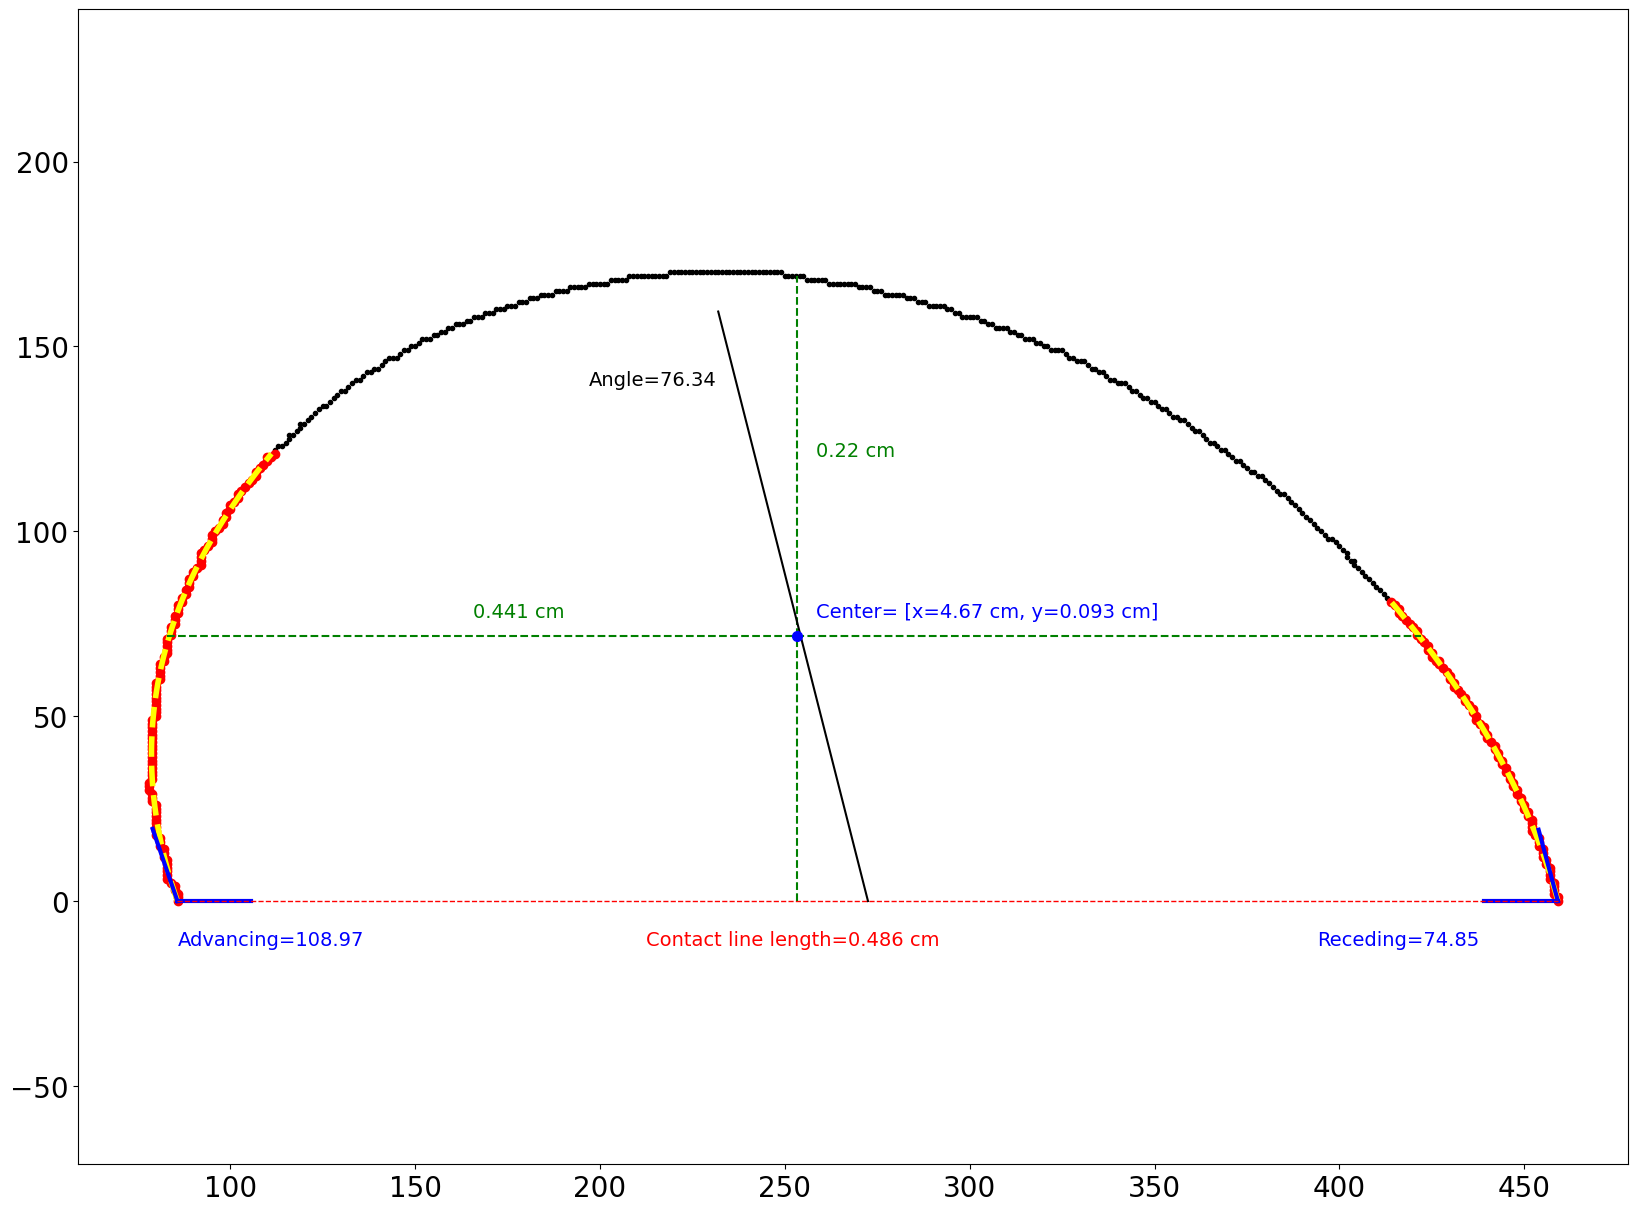

In [ ]:
# set variables
ad=r"toolkit-output-example"
fps=1000
cm_on_pixel_ratio= 0.0039062
error_handling_kernel_size=(5,5)
workflow_utils.make_folders(ad)

# --------------------------------------------------------------------------

model=edge_superres.model_architecture("SuperRes_weights.h5")
angle, rotated1, red1_xs, red1_ys, red2_xs, red2_ys= workflow_utils.slope_measurement(ad)
baseline=min(workflow_utils.find_reds(rotated1)[1])-1
name_files=workflow_utils.load_files(ad)
img_frame=cv2.imread(os.path.join(ad, name_files[0]))
img_frame_rotated=workflow_utils.rotate_image(img_frame, angle)

adv_list, rec_list, contact_line_length_list, x_center_list, y_center_list, middle_angle_degree_list,processed_number_list=[],[],[],[],[],[],[]
rec_angle_point_list, adv_angle_point_list=[],[]

num_px_ratio=(0.0039062)/cm_on_pixel_ratio
for file_number in range(1, len(name_files)):
    print(file_number,end=", ")

    img_drop=cv2.imread(os.path.join(ad, name_files[file_number]))
    img_drop_rotated=workflow_utils.rotate_image(img_drop, angle)

    #drop diff
    diff_img=cv2.absdiff(img_drop_rotated, img_frame_rotated)

    #drop cropping
    BaseL=baseline_detection.Baseline(baseline, middle_drop_height=25,drop_start_height=3*3, object_detection_threshold=40)
    drop_reflection,*dim=BaseL.drop_cropping(diff_img, x_left_margin=30, x_right_margin=60,y_up_margin=10)
    just_drop =diff_img[dim[2]:baseline,dim[0]:dim[1],:]

    #super resolution    
    
    upscaled_image=edge_superres.upscale_image(model, cv2.cvtColor(just_drop.astype('uint8'), cv2.COLOR_BGR2RGB))

    #utilizing morphological transformation to remove noises
    kernel = np.ones(error_handling_kernel_size,np. uint8) 
    upscaled_image=cv2.morphologyEx(np.array(upscaled_image), cv2.MORPH_CLOSE, kernel)

    #keeping just external pixels as droplet curvature
    i_list, j_list =edge_superres.edge_extraction( upscaled_image, thr=40)

    #extracting the desired number of pixels as input of the polynomial fitting 
    left_number_of_pixels=int(150*num_px_ratio)
    right_number_of_pixels=int(65*num_px_ratio)
    i_left, j_left=criteria_definition.advancing_pixel_selection(i_list,j_list, left_number_of_pixels=left_number_of_pixels)
    i_right, j_right=criteria_definition.receding_pixel_selection(i_list,j_list, right_number_of_pixels=right_number_of_pixels)

    #rotation for fitting, it can increase the accuracy to rotate 90 degrees then fit the polynomial
    i_left_rotated,j_left_rotated=j_left,i_left       
    i_right_rotated,j_right_rotated=j_right,i_right   

    left_polynomial_degree=3
    right_polynomial_degree=2
    i_poly_left_rotated, j_poly_left_rotated=criteria_definition.poly_fitting(i_left_rotated,j_left_rotated,polynomial_degree=left_polynomial_degree,line_space=left_number_of_pixels)
    i_poly_right_rotated, j_poly_right_rotated=criteria_definition.poly_fitting(i_right_rotated,j_right_rotated,polynomial_degree=right_polynomial_degree,line_space=right_number_of_pixels)

    right_angle_degree,right_angle_point=criteria_definition.right_angle(i_poly_right_rotated, j_poly_right_rotated,1)
    left_angle_degree,left_angle_point=criteria_definition.left_angle(i_poly_left_rotated, j_poly_left_rotated,1)
    

    if left_angle_degree<=60 :
        left_number_of_pixels=int(60*num_px_ratio)
        left_polynomial_degree=2
    elif 60<left_angle_degree<=105:
        left_number_of_pixels=int(85*num_px_ratio)
        left_polynomial_degree=2
    elif 105<left_angle_degree<=135:
        left_number_of_pixels=int(125*num_px_ratio)  #175
        left_polynomial_degree=3
    elif 135<left_angle_degree:
        left_number_of_pixels=int(145*num_px_ratio) #215
        left_polynomial_degree=4

    if right_angle_degree<=60:
        right_number_of_pixels=int(60*num_px_ratio)
        right_polynomial_degree=2
    elif 60<right_angle_degree<=105:
        right_number_of_pixels=int(85*num_px_ratio)
        right_polynomial_degree=2
    elif 105<right_angle_degree<=135:
        right_number_of_pixels=int(125*num_px_ratio) #175
        right_polynomial_degree=3
    elif 135<right_angle_degree:
        right_number_of_pixels=int(145*num_px_ratio) #215
        right_polynomial_degree=4

    #9. extracting the desired number of pixels as input of the polynomial fitting 
    i_left, j_left=criteria_definition.advancing_pixel_selection(i_list,j_list, left_number_of_pixels=left_number_of_pixels)
    i_right, j_right=criteria_definition.receding_pixel_selection(i_list,j_list, right_number_of_pixels=right_number_of_pixels)

    #10. rotation for fitting, it can increase the accuracy to rotate 90 degrees and then fit the polynomial
    i_left_rotated,j_left_rotated=j_left,i_left       
    i_right_rotated,j_right_rotated=j_right,i_right   
    i_poly_left_rotated, j_poly_left_rotated=criteria_definition.poly_fitting(i_left_rotated,j_left_rotated,polynomial_degree=left_polynomial_degree,line_space=left_number_of_pixels)
    i_poly_right_rotated, j_poly_right_rotated=criteria_definition.poly_fitting(i_right_rotated,j_right_rotated,polynomial_degree=right_polynomial_degree,line_space=right_number_of_pixels)
    j_poly_left=i_poly_left_rotated
    i_poly_left=j_poly_left_rotated
    j_poly_right=i_poly_right_rotated
    i_poly_right=j_poly_right_rotated
    x_cropped=dim[0]

    distance = (x_cropped) * 3
    address=os.path.join(ad, 'SR_edge', str(name_files[file_number]))
    adv, rec,rec_angle_point, adv_angle_point, contact_line_length, x_center, y_center, middle_angle_degree=visualization.visualize(address, 
                                                                                                                                   distance+np.array(i_list),j_list,distance+np.array(i_left),j_left,distance+np.array(i_right),j_right,
                                                                                                                                   j_poly_left,distance+np.array(i_poly_left),j_poly_right,distance+np.array(i_poly_right),x_cropped,
                                                                                                                                   distance+np.array(i_poly_left_rotated), j_poly_left_rotated, distance+np.array(i_poly_right_rotated),
                                                                                                                                   j_poly_right_rotated, cm_on_pixel=cm_on_pixel_ratio, middle_line_switch=1)
    processed_number_list.append(int(name_files[file_number].split(".")[0].split("S0001")[-1]))
    adv_list.append(adv)
    rec_list.append(rec)
    adv_angle_point_list.append(adv_angle_point)
    rec_angle_point_list.append(rec_angle_point)
    contact_line_length_list.append(contact_line_length)
    x_center_list.append(x_center)
    y_center_list.append(y_center)
    middle_angle_degree_list.append(middle_angle_degree)

vel=[]
for i in range(len(x_center_list)-1):
    vel=vel+[x_center_list[i+1]-x_center_list[i]]

vel=np.array(vel)*fps
df=pd.DataFrame([processed_number_list, np.arange(0, 1/fps*len(vel), 1/fps), x_center_list, adv_list,rec_list,contact_line_length_list, y_center_list, middle_angle_degree_list, vel]).T
df=df[:-1]

df.columns=['file number', "time (s)", 'x_center (cm)', 'adv (degree)', 'rec (degree)', 'contact_line_length (cm)', 'y_center (cm)', 'middle_angle_degree (degree)', 'velocity (cm/s)']

filter_size=9


df["adv (degree)"]=savgol_filter(df["adv (degree)"], filter_size, 2)

df["rec (degree)"]=savgol_filter(df["rec (degree)"], filter_size, 2)

df["contact_line_length (cm)"]=savgol_filter(df["contact_line_length (cm)"], filter_size, 2)

df["y_center (cm)"]=savgol_filter(df["y_center (cm)"], filter_size, 2)

df["middle_angle_degree (degree)"]=savgol_filter(df["middle_angle_degree (degree)"], filter_size, 2)

df["velocity (cm/s)"]=savgol_filter(df["velocity (cm/s)"], filter_size, 2)


df.to_excel(os.path.join(ad, 'SR_result', 'result.xlsx'))

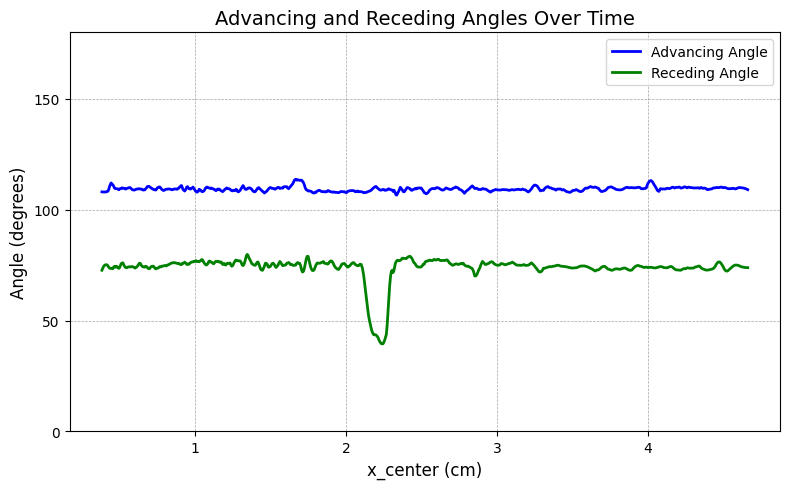

In [3]:
plt.figure(figsize=(8, 5))  # Adjust the size of the figure
plt.plot(df["x_center (cm)"], df["adv (degree)"], label="Advancing Angle", color="blue", linestyle="-", linewidth=2)
plt.plot(df["x_center (cm)"], df["rec (degree)"], label="Receding Angle", color="green", linestyle="-", linewidth=2)

# Adding titles and labels
plt.title("Advancing and Receding Angles Over Time", fontsize=14)
plt.xlabel("x_center (cm)", fontsize=12)
plt.ylabel("Angle (degrees)", fontsize=12)

# Customizing the grid
plt.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.7)

plt.ylim(0, 180)

# Adding a legend
plt.legend(fontsize=10, loc="best")

# Improving axis ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Display the plot
plt.tight_layout()  # Ensures everything fits well
plt.show()
